In [1]:
#load dependencies
import fastf1
import pandas
import matplotlib.pyplot as plt
import numpy as np

In [2]:
totalLapNumber = 58
fuel_burn_per_lap = 110/58  # kg/lap
time_per_10kg = 0.3      # seconds
# Fuel correction calculation
time_per_kg = time_per_10kg / 10
fuelLapCorrections = []
current_fuel = fuel_burn_per_lap * totalLapNumber

for lap in range(totalLapNumber):
    fuelLapCorrections.append(current_fuel * time_per_kg)
    current_fuel -= fuel_burn_per_lap

In [5]:
from scipy.special import expit  # Sigmoid function

# Tyre parameters with smooth degradation curves
tyre_params = {
    "C5": {
        "base": 88.000,
        "initial_gain": -0.3,  # Total time gained during warm-up (e.g., -0.1s/lap × 3 laps)
        "wear": 0.110,
        "peak_laps": 3,
        "cliff_start": 7,
        "cliff_strength": 0.45  # How abrupt the cliff is
    },
    "C4": {
        "base": 88.700,
        "initial_gain": -0.5,
        "wear": 0.070,
        "peak_laps": 10,
        "cliff_start": 15,
        "cliff_strength": 0.35
    },
    "C3": {
        "base": 89.300,
        "initial_gain": -0.8,
        "wear": 0.050,
        "peak_laps": 14,
        "cliff_start": 20,
        "cliff_strength": 0.25
    }
}

def smooth_tyre_performance(compound, lap_age):
    """Enhanced smooth transition between phases"""
    p = tyre_params[compound]
    
    # Phase 1: Initial improvement (sigmoid peak)
    warmup = p["initial_gain"] * expit(-(lap_age - p["peak_laps"]) * 0.1)  # Tighter peak
    
    # Phase 2: Blended degradation (smooth transition)
    progress = (lap_age - p["peak_laps"]) / (p["cliff_start"] - p["peak_laps"])
    blend = expit((progress - 0.3) * 7)  # Smooth blending factor (0 to 1)
    
    linear_deg = p["wear"] * max(0, lap_age - p["peak_laps"]) * blend
    
    # Phase 3: Performance cliff (delayed sigmoid)
    cliff = p["cliff_strength"] * max(0, lap_age - p["cliff_start"]) * expit((lap_age - p["cliff_start"]) * 0.3)
    
    return warmup + linear_deg + cliff

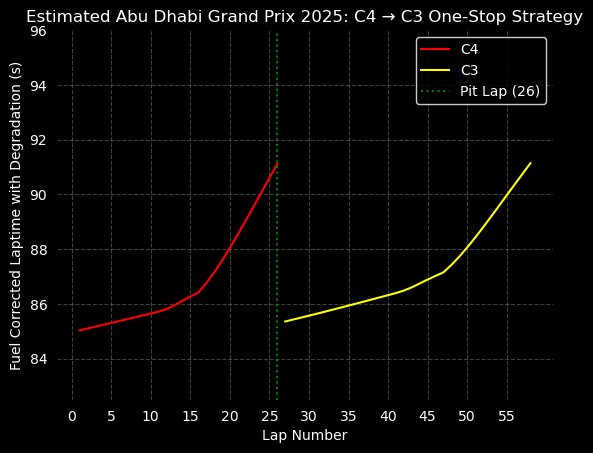

In [13]:
pitLap = 26
pitTime = 22
def get_fuel_corrections(start_fuel):
    """Generates fuel corrections starting from specified fuel load"""
    corrections = []
    current_fuel = start_fuel
    for _ in range(totalLapNumber):
        corrections.append(current_fuel * (time_per_10kg/10))
        current_fuel -= fuel_burn_per_lap
    return corrections

# Calculate stints with RESET fuel corrections
def calculate_stint(compound, start_lap, end_lap, start_fuel):
    lap_times = []
    fuel_corr = get_fuel_corrections(start_fuel)
    for lap in range(start_lap, end_lap + 1):
        tyre_age = lap - start_lap  # Tyre age resets at stint start
        base_time = tyre_params[compound]["base"]
        tyre_effect = smooth_tyre_performance(compound, tyre_age)
        fuel_effect = fuel_corr[lap - start_lap]  # Fuel correction reset
        
        lap_time = base_time + tyre_effect - fuel_effect
        lap_times.append(lap_time)
    return lap_times

# Calculate both stints
full_fuel = fuel_burn_per_lap * totalLapNumber
first_stint = calculate_stint("C4", 1, pitLap, full_fuel)
second_stint = calculate_stint("C3", pitLap + 1, totalLapNumber, full_fuel)

# Plotting
fig, ax = plt.subplots()
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# Plot data
laps = list(range(1, totalLapNumber + 1))
plt.plot(laps[:pitLap], first_stint, color='red', label='C4')
plt.plot(laps[pitLap:], second_stint, color='yellow', label='C3')
plt.axvline(x=pitLap, color='green', linestyle=':', label=f'Pit Lap ({pitLap})')

# Formatting
plt.title("Estimated Abu Dhabi Grand Prix 2025: C4 → C3 One-Stop Strategy", color='white')
plt.xlabel("Lap Number", color='white')
plt.ylabel("Fuel Corrected Laptime with Degradation (s)", color='white')
plt.ylim(82.5,96)
plt.xticks(np.arange(0, totalLapNumber + 1, 5), color='white')
plt.yticks(color='white')
plt.grid(color='gray', linestyle='--', alpha=0.5)
plt.legend(facecolor='black', edgecolor='white', labelcolor='white')

plt.show()

In [9]:
totalRaceTime_sec = sum(first_stint) + sum(second_stint) + pitTime
totalRaceTime_min = totalRaceTime_sec//60
totalRaceTime_min_sec = totalRaceTime_sec % 60
print("The total race time is:", totalRaceTime_sec, "seconds.")
print("Or, it is 1:",totalRaceTime_min-60,":",totalRaceTime_min_sec,)

The total race time is: 5070.464839363949 seconds.
Or, it is 1: 24.0 : 30.464839363949068


In [11]:
print(first_stint)
print(second_stint)

[85.034470710685, 85.10142180041164, 85.16880586288447, 85.23659576908834, 85.30475805378366, 85.37325309301976, 85.4420354802886, 85.51105460366313, 85.58025541513688, 85.64957937177778, 85.71896551724139, 85.81157851865322, 85.95122190744944, 86.11396609836855, 86.26768812958377, 86.4120909019925, 86.75345802722734, 87.14307289486311, 87.5755596234838, 88.04242658348436, 88.53421090388555, 89.04206911335582, 89.5586989708945, 90.07865453833179, 90.59824308947127, 91.11521046857715]
[85.35825288915314, 85.42822856529008, 85.49897327664905, 85.57048157069632, 85.64273934399255, 85.71572315652068, 85.78939972544273, 85.86372564433444, 85.93864736881247, 86.01410150055575, 86.09001538915142, 86.1663080555162, 86.24289142283968, 86.31967182243064, 86.39655172413792, 86.48754407299732, 86.60601903602358, 86.74712297604347, 86.88882510871147, 87.02316331860087, 87.1522386170601, 87.42217869933656, 87.72624324044685, 88.06049125117733, 88.41885387802901, 88.7945779798783, 89.18134950006085, 